In [1]:
# the discrete case

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np 

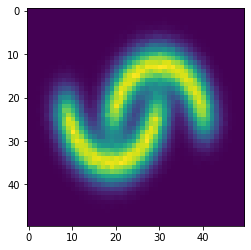

In [9]:
# two moon 

# producing matching results

# Neural Networks

X, y = make_moons(n_samples=1000000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train = X_train-X_train.min(0)
X_train = X_train/X_train.max(0)

# Define the range for both axes
axis_range = [(0, 1), (0, 1)]

# Define the number of bins
bins = 50

# Calculate the 2D histogram and return the matrix of histogram values
hist, xedges, yedges = np.histogram2d(X_train[:, 0], X_train[:, 1], bins=bins, range=axis_range, density=True)

# Normalize the histogram to make it a PDF
pdf = hist / np.sum(hist)
pdf = torch.from_numpy(pdf.T)

plt.imshow(pdf)
plt.show()

# run_dataset.append(X_train[:100000])
# pdf_list.append(pdf)

train_data = torch.from_numpy(X_train).float()

In [11]:
class encoder(nn.Module):
    def __init__(self, input_dim = 784, HIDDEN = 500, out_dim = 200):
        super(encoder, self).__init__()
        self.dim = out_dim
    
        self.fc1 = nn.Linear(input_dim+5, HIDDEN, bias=True)
        self.bn1 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn2 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn3 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc4 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn4 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc6 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn6 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc7 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn7 = torch.nn.BatchNorm1d(HIDDEN)

        self.fc5 = nn.Linear(HIDDEN, out_dim, bias=True)

    def forward(self, x):
        
        x = torch.cat((x, torch.zeros((x.shape[0], 5)).uniform_().cuda()), 1)
        x = torch.relu(self.bn1((self.fc1(x))))
        x = torch.relu(self.bn2((self.fc2(x))))
        x = torch.relu(self.bn3((self.fc3(x))))
        x = torch.relu(self.bn4((self.fc4(x))))
        x = torch.relu(self.bn6((self.fc6(x))))

        x = torch.sigmoid(self.fc5(x))

        return x

iteration: 100 cost: 3.5906765460968018
iteration: 200 cost: 4.14938497543335
iteration: 300 cost: 4.553747177124023
iteration: 400 cost: 4.703245162963867
iteration: 500 cost: 4.835081100463867
iteration: 600 cost: 5.001173496246338
iteration: 700 cost: 5.09827184677124
iteration: 800 cost: 5.165091514587402
iteration: 900 cost: 5.228320598602295
iteration: 1000 cost: 5.241785049438477


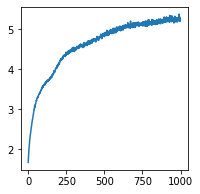

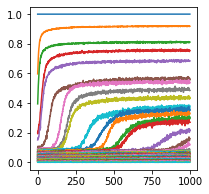

iteration: 1100 cost: 5.27958869934082
iteration: 1200 cost: 5.398567199707031
iteration: 1300 cost: 5.427931308746338
iteration: 1400 cost: 5.392594337463379
iteration: 1500 cost: 5.44207763671875
iteration: 1600 cost: 5.604644298553467
iteration: 1700 cost: 5.499608516693115
iteration: 1800 cost: 5.469060897827148
iteration: 1900 cost: 5.533923149108887
iteration: 2000 cost: 5.514254570007324


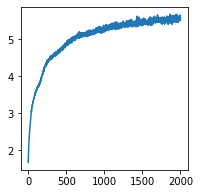

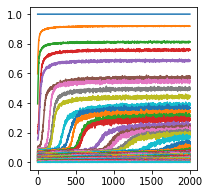

iteration: 2100 cost: 5.588778972625732
iteration: 2200 cost: 5.5101704597473145
iteration: 2300 cost: 5.590577602386475
iteration: 2400 cost: 5.687200546264648
iteration: 2500 cost: 5.697303771972656
iteration: 2600 cost: 5.679056167602539
iteration: 2700 cost: 5.670533180236816
iteration: 2800 cost: 5.70626163482666
iteration: 2900 cost: 5.683435916900635
iteration: 3000 cost: 5.61666202545166


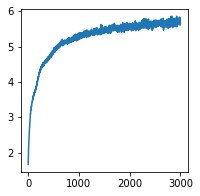

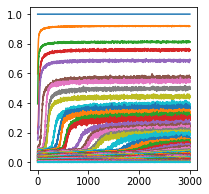

iteration: 3100 cost: 5.603228569030762
iteration: 3200 cost: 5.7402873039245605
iteration: 3300 cost: 5.667679309844971
iteration: 3400 cost: 5.810817718505859
iteration: 3500 cost: 5.726469993591309
iteration: 3600 cost: 5.69849967956543
iteration: 3700 cost: 5.7659759521484375
iteration: 3800 cost: 5.856409072875977
iteration: 3900 cost: 5.716951370239258
iteration: 4000 cost: 5.913949966430664


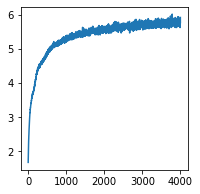

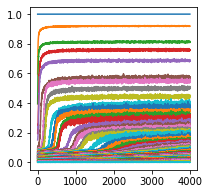

iteration: 4100 cost: 5.906423568725586
iteration: 4200 cost: 5.671609878540039
iteration: 4300 cost: 5.831955909729004
iteration: 4400 cost: 5.769684791564941
iteration: 4500 cost: 5.729881763458252
iteration: 4600 cost: 5.927196502685547
iteration: 4700 cost: 5.822729587554932
iteration: 4800 cost: 5.923192024230957
iteration: 4900 cost: 5.861005783081055
iteration: 5000 cost: 6.077302932739258


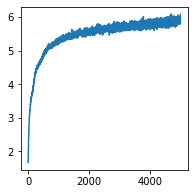

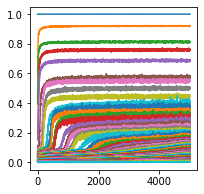

In [31]:
# trace cost 

torch.cuda.set_device(2)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

def adaptive_estimation(v_t, beta, square_term, i):
    v_t = beta*v_t + (1-beta)*square_term.detach()
    return v_t, (v_t/(1-beta**i))

def produce_CC_GRAD_ALL_new(cat_vector, track_cov, i, threshold):
    XY = cat_vector.T@cat_vector/cat_vector.shape[0]
    cov = XY + torch.eye((XY.shape[0])).cuda()*(threshold)
    track_cov, cov_estimate = adaptive_estimation(track_cov, 0.5, cov, i)
    return cov_estimate, cov, track_cov

NET_F = encoder(input_dim = 2, out_dim = 50).cuda()
NET_G = encoder(input_dim = 2, out_dim = 50).cuda()

optimizer_F = optim.Adam([
      {'params': NET_F.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

optimizer_G = optim.Adam([
      {'params': NET_G.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

error_curve = []
eig_curve = []

for i in range(1, 5001):
    
    b1 = np.random.choice(train_data.shape[0], 20000)
    batch_data = train_data[b1].cuda()
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_()*1e-1

    f = NET_F(batch_data)
    g = NET_G(noise_data)

    RF = f.T@f/f.shape[0]
    RG = g.T@g/g.shape[0]
    P = f.T@g/f.shape[0]
    
    RF = RF + torch.eye(RF.shape[0]).cuda()*1e-6
    RG = RG + torch.eye(RG.shape[0]).cuda()*1e-6    
    
    cost = torch.trace(torch.inverse(RF)@P@torch.inverse(RG)@P.T)
    (-cost).backward()
    
    error_curve.append(cost.item())
    
    
    # log-determinant cost:
    
# #     dim = 50
# #     RFG = torch.zeros((dim*2, dim*2)).cuda()
# #     RFG[:dim, :dim] = RF
# #     RFG[dim:, dim:] = RG
# #     RFG[:dim, dim:] = P
# #     RFG[dim:, :dim] = P.T
    
# #     cost = torch.logdet(RFG) - torch.logdet(RF) - torch.logdet(RG)
# #     (cost).backward()

    
    # track eigenvalues at each step. Can be commented.
    with torch.no_grad():
        
        Sigma, Q = torch.linalg.eigh(RF) 
        RF_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        Sigma, Q = torch.linalg.eigh(RG) 
        RG_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        P_STAR = RF_NORM@P@RG_NORM    
        U,S,V = torch.svd(P_STAR)

        eig_curve.append(S.detach().cpu().numpy())


    
    
    optimizer_F.step()
    optimizer_G.step()

    optimizer_F.zero_grad()
    optimizer_G.zero_grad()

    
    if i%100 == 0:
        print('iteration:', i, 'cost:', cost.item())
        
        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.plot(error_curve)
            plt.show()
            
            plt.figure(figsize=(3, 3))
            plt.plot(eig_curve)
            plt.show()

iteration: 100 cost: -0.0703582763671875
iteration: 200 cost: -0.088165283203125
iteration: 300 cost: -0.06573486328125
iteration: 400 cost: -0.03594970703125
iteration: 500 cost: -0.0399169921875
iteration: 600 cost: -0.031494140625
iteration: 700 cost: -0.05126953125
iteration: 800 cost: -0.0787353515625
iteration: 900 cost: -0.07379150390625
iteration: 1000 cost: -0.040283203125


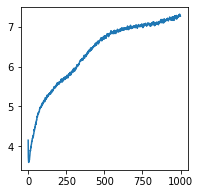

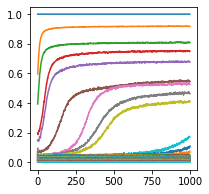

iteration: 1100 cost: 0.001953125
iteration: 1200 cost: -0.0740966796875
iteration: 1300 cost: -0.04083251953125
iteration: 1400 cost: -0.02392578125
iteration: 1500 cost: -0.0595703125
iteration: 1600 cost: -0.0888671875
iteration: 1700 cost: 0.02362060546875
iteration: 1800 cost: -0.01654052734375
iteration: 1900 cost: -0.0244140625
iteration: 2000 cost: -0.00701904296875


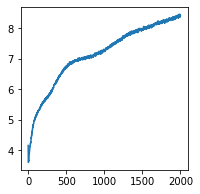

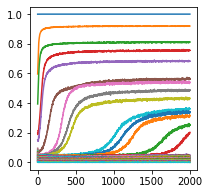

iteration: 2100 cost: -0.0599365234375
iteration: 2200 cost: -0.04718017578125
iteration: 2300 cost: -0.02191162109375
iteration: 2400 cost: -0.04290771484375
iteration: 2500 cost: -0.0823974609375
iteration: 2600 cost: -0.03582763671875
iteration: 2700 cost: -0.0289306640625
iteration: 2800 cost: -0.05718994140625
iteration: 2900 cost: -0.0567626953125
iteration: 3000 cost: -0.01092529296875


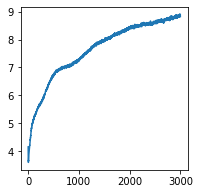

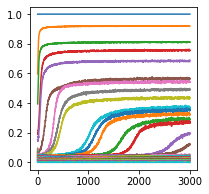

iteration: 3100 cost: 0.0166015625
iteration: 3200 cost: -0.00360107421875
iteration: 3300 cost: -0.05828857421875
iteration: 3400 cost: -0.08001708984375
iteration: 3500 cost: 0.0157470703125
iteration: 3600 cost: 0.00323486328125
iteration: 3700 cost: -0.07940673828125
iteration: 3800 cost: 0.002685546875
iteration: 3900 cost: -0.0345458984375
iteration: 4000 cost: -0.08685302734375


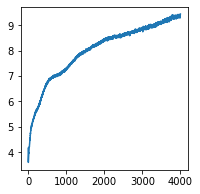

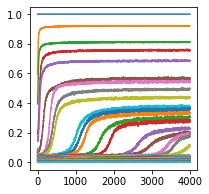

iteration: 4100 cost: -0.0906982421875
iteration: 4200 cost: 0.0106201171875
iteration: 4300 cost: -0.0882568359375
iteration: 4400 cost: -0.05780029296875
iteration: 4500 cost: 0.00067138671875
iteration: 4600 cost: -0.0703125
iteration: 4700 cost: -0.0220947265625
iteration: 4800 cost: -0.102783203125
iteration: 4900 cost: 0.00390625
iteration: 5000 cost: -0.125


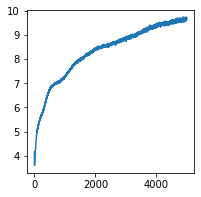

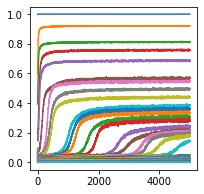

In [34]:
# log determinant cost 

torch.cuda.set_device(2)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

def adaptive_estimation(v_t, beta, square_term, i):
    v_t = beta*v_t + (1-beta)*square_term.detach()
    return v_t, (v_t/(1-beta**i))

def produce_CC_GRAD_ALL_new(cat_vector, track_cov, i, threshold):
    XY = cat_vector.T@cat_vector/cat_vector.shape[0]
    cov = XY + torch.eye((XY.shape[0])).cuda()*(threshold)
    track_cov, cov_estimate = adaptive_estimation(track_cov, 0.5, cov, i)
    return cov_estimate, cov, track_cov

NET_F = encoder(input_dim = 2, out_dim = 50).cuda()
NET_G = encoder(input_dim = 2, out_dim = 50).cuda()

optimizer_F = optim.Adam([
      {'params': NET_F.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

optimizer_G = optim.Adam([
      {'params': NET_G.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

error_curve = []
eig_curve = []


track_cov = torch.zeros((50+50, 50+50)).float().cuda()


for i in range(1, 5001):
    
    b1 = np.random.choice(train_data.shape[0], 20000)
    batch_data = train_data[b1].cuda()
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_()*1e-1

    f = NET_F(batch_data)
    g = NET_G(noise_data)

    

    # we can use a tracker to smooth the gradient
    
    units_f = 50
    
    cat_vector = torch.cat((f, g), 1)
    cov_estimate, cov, track_cov = produce_CC_GRAD_ALL_new(cat_vector, track_cov, i, 1e-5)

    cov_estimate_f = cov_estimate[:units_f, :units_f]
    cov_f = cov[:units_f, :units_f]

    cov_estimate_g = cov_estimate[units_f:, units_f:]
    cov_g = cov[units_f:, units_f:]

    cost = (torch.linalg.inv(cov_estimate)*cov).sum() - (torch.linalg.inv(cov_estimate_f)*cov_f).sum() - (torch.linalg.inv(cov_estimate_g)*cov_g).sum()
    (cost).backward()

    
    
    with torch.no_grad():
        
        RF, RG, P = cov_estimate[:units_f, :units_f], cov_estimate[units_f:, units_f:], cov_estimate[:units_f, units_f:]

        Sigma, Q = torch.linalg.eigh(RF) 
        RF_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        Sigma, Q = torch.linalg.eigh(RG) 
        RG_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        P_STAR = RF_NORM@P@RG_NORM    
        U,S,V = torch.svd(P_STAR)

        eig_curve.append(S.detach().cpu().numpy())
        error_curve.append(S.detach().cpu().numpy().sum())
        
    
    
    optimizer_F.step()
    optimizer_G.step()

    optimizer_F.zero_grad()
    optimizer_G.zero_grad()

    
    if i%100 == 0:
        print('iteration:', i, 'cost:', cost.item())
        
        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.plot(error_curve)
            plt.show()
            
            plt.figure(figsize=(3, 3))
            plt.plot(eig_curve)
            plt.show()

In [35]:
class encoder2(nn.Module):
    def __init__(self, input_dim = 784, HIDDEN = 500, out_dim = 200):
        super(encoder2, self).__init__()
        self.dim = out_dim
    
        self.fc1 = nn.Linear(input_dim+5, HIDDEN, bias=True)
        self.bn1 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn2 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn3 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc4 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn4 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc6 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn6 = torch.nn.BatchNorm1d(HIDDEN)
        self.fc7 = nn.Linear(HIDDEN, HIDDEN, bias=True)
        self.bn7 = torch.nn.BatchNorm1d(HIDDEN)

        self.fc5 = nn.Linear(HIDDEN, out_dim, bias=True)

    def forward(self, x):
        
        x = torch.cat((x, torch.zeros((x.shape[0], 5)).uniform_().cuda()), 1)
        x = torch.relu(self.bn1((self.fc1(x))))
        x = torch.relu(self.bn2((self.fc2(x))))
        x = torch.relu(self.bn3((self.fc3(x))))
        x = torch.relu(self.bn4((self.fc4(x))))
        x = torch.relu(self.bn6((self.fc6(x))))

        x = torch.relu(self.fc5(x))

        return x


iteration: 100 cost: -2.8326005935668945
iteration: 200 cost: -3.9322075843811035
iteration: 300 cost: -4.534641265869141
iteration: 400 cost: -4.77929162979126
iteration: 500 cost: -4.933653831481934
iteration: 600 cost: -5.084550380706787
iteration: 700 cost: -5.104082107543945
iteration: 800 cost: -5.157920837402344
iteration: 900 cost: -5.218862056732178
iteration: 1000 cost: -5.212780952453613


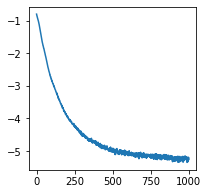

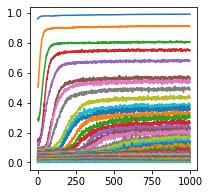

iteration: 1100 cost: -5.228377819061279
iteration: 1200 cost: -5.314129829406738
iteration: 1300 cost: -5.32700252532959
iteration: 1400 cost: -5.267991065979004
iteration: 1500 cost: -5.295977592468262
iteration: 1600 cost: -5.4645209312438965
iteration: 1700 cost: -5.361517429351807
iteration: 1800 cost: -5.328009605407715
iteration: 1900 cost: -5.356984615325928
iteration: 2000 cost: -5.358977794647217


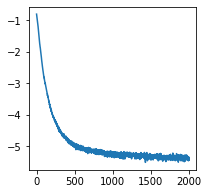

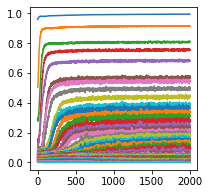

iteration: 2100 cost: -5.400704383850098
iteration: 2200 cost: -5.306408405303955
iteration: 2300 cost: -5.376160621643066
iteration: 2400 cost: -5.454184532165527
iteration: 2500 cost: -5.467033863067627
iteration: 2600 cost: -5.430500507354736
iteration: 2700 cost: -5.4227294921875
iteration: 2800 cost: -5.449219703674316
iteration: 2900 cost: -5.435865879058838
iteration: 3000 cost: -5.38295841217041


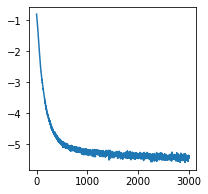

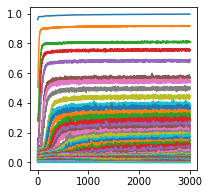

iteration: 3100 cost: -5.361953258514404
iteration: 3200 cost: -5.438525199890137
iteration: 3300 cost: -5.4068427085876465
iteration: 3400 cost: -5.483706951141357
iteration: 3500 cost: -5.431273937225342
iteration: 3600 cost: -5.4340105056762695
iteration: 3700 cost: -5.487727642059326
iteration: 3800 cost: -5.509041786193848
iteration: 3900 cost: -5.439728736877441
iteration: 4000 cost: -5.594497203826904


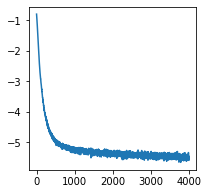

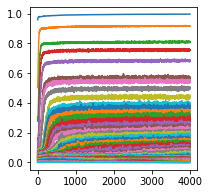

iteration: 4100 cost: -5.5867156982421875
iteration: 4200 cost: -5.380655765533447
iteration: 4300 cost: -5.564379692077637
iteration: 4400 cost: -5.475151062011719
iteration: 4500 cost: -5.459539413452148
iteration: 4600 cost: -5.57927131652832
iteration: 4700 cost: -5.494148254394531
iteration: 4800 cost: -5.53925895690918
iteration: 4900 cost: -5.493984699249268
iteration: 5000 cost: -5.659507751464844


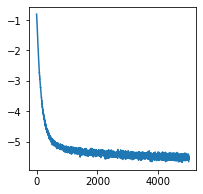

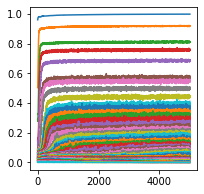

In [38]:
torch.cuda.set_device(2)

def gauss(A,B,var):
    return torch.exp(-((A.unsqueeze(1) - B.unsqueeze(0))**2).mean(2)/(2*var))

def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag

torch.manual_seed(0)
np.random.seed(0)

def adaptive_estimation(v_t, beta, square_term, i):
    v_t = beta*v_t + (1-beta)*square_term.detach()
    return v_t, (v_t/(1-beta**i))

def produce_CC_GRAD_ALL_new(cat_vector, track_cov, i, threshold):
    XY = cat_vector.T@cat_vector/cat_vector.shape[0]
    cov = XY + torch.eye((XY.shape[0])).cuda()*(threshold)
    track_cov, cov_estimate = adaptive_estimation(track_cov, 0.5, cov, i)
    return cov_estimate, cov, track_cov

NET_F = encoder2(input_dim = 2, out_dim = 50).cuda()
NET_G = encoder2(input_dim = 2, out_dim = 50).cuda()

optimizer_F = optim.Adam([
      {'params': NET_F.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

optimizer_G = optim.Adam([
      {'params': NET_G.parameters(), 'lr': 0.00001, 'betas': (0.9, 0.999)},
   ])

error_curve = []
eig_curve = []

for i in range(1, 5001):
    
    b1 = np.random.choice(train_data.shape[0], 20000)
    batch_data = train_data[b1].cuda()
    
    noise_data = batch_data + torch.zeros((batch_data.shape)).cuda().normal_()*1e-1

    f = NET_F(batch_data)
    g = NET_G(noise_data)
    
    numerator = ((f*g).mean(0)).mean()
    RF = f.T@f/f.shape[0]
    RG = g.T@g/g.shape[0]
    denominator = (RF*RG).mean()
    cost = -(numerator)**2/(denominator)
    cost.backward()
    
    error_curve.append(cost.item())
    
    
    
    with torch.no_grad():
        
        RF = f.T@f/f.shape[0]
        RG = g.T@g/g.shape[0]
        P = f.T@g/f.shape[0]

        RF = RF + torch.eye(RF.shape[0]).cuda()*1e-6
        RG = RG + torch.eye(RG.shape[0]).cuda()*1e-6    

        Sigma, Q = torch.linalg.eigh(RF) 
        RF_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        Sigma, Q = torch.linalg.eigh(RG) 
        RG_NORM = (Q@torch.diag(Sigma**(-1/2))@Q.T) 

        P_STAR = RF_NORM@P@RG_NORM    
        U,S,V = torch.svd(P_STAR)

        eig_curve.append(S.detach().cpu().numpy())
        
        
        
        

    optimizer_F.step()
    optimizer_G.step()

    optimizer_F.zero_grad()
    optimizer_G.zero_grad()

    
    if i%100 == 0:
        print('iteration:', i, 'cost:', cost.item())
        
        if i%1000 == 0:
            plt.figure(figsize=(3, 3))
            plt.plot(error_curve)
            plt.show()
            
            plt.figure(figsize=(3, 3))
            plt.plot(eig_curve)
            plt.show()